In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.append("../..")
sys.path.append("../../..")

# 1. Open dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
path = "/data/pcpe/pcpe_03.csv"
df = pd.read_csv(path, delimiter=';', decimal=',')
df

/tmp/ipykernel_1751/1803422712.py:2: DtypeWarning: Columns (29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, delimiter=';', decimal=',')


,NUMERO_CASO,NUMERO_BANCO,NOME_BANCO,NUMERO_AGENCIA,NUMERO_CONTA,TIPO,CPF_CNPJ_TITULAR,NOME_TITULAR,DATA_LANCAMENTO,CPF_CNPJ_OD,...,VALOR_SALDO,NATUREZA_SALDO,NUMERO_BANCO_OD,NUMERO_AGENCIA_OD,NUMERO_CONTA_OD,NOME_ENDOSSANTE_CHEQUE,DOC_ENDOSSANTE_CHEQUE,DIA_LANCAMENTO,MES_LANCAMENTO,ANO_LANCAMENTO
0,EXTRATO-2.0-F0R0B8,237,BANCO BRADESCO S.A,2764,10081653,2,37469951830,MARTA VILLADICANI,2019-02-22 00:00:00,0,...,128065.54,C,0,0,NaN,NaN,NaN,22,2,2019
1,EXTRATO-2.0-F0R0B8,237,BANCO BRADESCO S.A,2764,10081653,2,37469951830,MARTA VILLADICANI,2019-02-27 00:00:00,0,...,131594.18,C,0,0,NaN,NaN,NaN,27,2,2019
2,EXTRATO-2.0-F0R0B8,237,BANCO BRADESCO S.A,2764,10081653,2,37469951830,MARTA VILLADICANI,2019-02-27 00:00:00,0,...,131688.04,C,0,0,NaN,NaN,NaN,27,2,2019
3,EXTRATO-2.0-F0R0B8,237,BANCO BRADESCO S.A,2764,10081653,2,37469951830,MARTA VILLADICANI,2019-04-02 00:00:00,0,...,135574.62,C,0,0,NaN,NaN,NaN,2,4,2019
4,EXTRATO-2.0-F0R0B8,237,BANCO BRADESCO S.A,2764,10081653,2,37469951830,MARTA VILLADICANI,2019-04-30 00:00:00,0,...,135819.30,C,0,0,NaN,NaN,NaN,30,4,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167027,EXTRATO-2.0-F0R0B8,237,BANCO BRADESCO S.A,3929,5251117,1,6745923440,MORENA GALEATI,2022-10-31 00:00:00,43808741000106,...,7066.60,C,403,1,4738204.0,NaN,NaN,31,10,2022
167028,EXTRATO-2.0-F0R0B8,237,BANCO BRADESCO S.A,3929,5251117,1,6745923440,MORENA GALEATI,2022-10-31 00:00:00,43808741000106,...,5323.10,C,403,1,4738204.0,NaN,NaN,31,10,2022
167029,EXTRATO-2.0-F0R0B8,237,BANCO BRADESCO S.A,3929,5251117,1,6745923440,MORENA GALEATI,2022-10-31 00:00:00,10585973458,...,9066.60,C,336,1,7924406.0,NaN,NaN,31,10,2022
167030,EXTRATO-2.0-F0R0B8,237,BANCO BRADESCO S.A,3929,5251117,1,6745923440,MORENA GALEATI,2022-10-31 00:00:00,10585973458,...,13145.15,C,336,1,7924406.0,NaN,NaN,31,10,2022


In [24]:
from publications.lacci2024.analysis import LacciAnalysis


# 2. Descriptive Statistics

In [25]:
lacci_analysis = LacciAnalysis(df) 
df_descriptive = lacci_analysis.get_results_descriptive()
print(df_descriptive.to_latex())


\begin{tabular}{lrrrr}
\toprule
Typology & I-d & I-e & IV-n & None \\
\midrule
Accounts & 40 & 35 & 12 & 169 \\
Individuals/Companies & 15 & 12 & 5 & 23 \\
Transactions & 12393 & 1362 & 7371 & 145906 \\
\bottomrule
\end{tabular}



# 3. Data Spliting

In [7]:
from mlex import PastFutureSplit
split = PastFutureSplit()
X, y = lacci_analysis.get_X_y()
X_train, X_test, y_train, y_test = split.train_test_split(X, y)


2025-02-13 00:06:51.461305: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-13 00:06:51.472743: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-13 00:06:51.476222: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-13 00:06:51.485231: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [8]:
print(X_train.size)
print(X_test.size)
print(y_train.size)
print(y_test.size)


3674704
3674660
83516
83515


# 4. Model Training

In [9]:
from mlex import (
    SimplePipeline,
    SimpleRNNModel,
    SimpleLSTMModel,
    SimpleGruModel,
)

In [ ]:
from mlex import (
    SequenceTransformer
)

In [ ]:
import tensorflow as tf
sequence_length = 20
sequence = SequenceTransformer(sequence_length=sequence_length)
data_test = sequence.transform(X_test, y_test)

data_train_full = sequence.transform(X_train, y_train)

N = len(data_train_full)
train_size = int(0.7 * N)
val_size = int(0.3 * N)

data_train = data_train_full.take(train_size)
data_val = data_train_full.skip(train_size)


I0000 00:00:1739416022.247676   67466 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739416022.257137   67466 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739416022.260478   67466 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1739416022.264859   67466 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [17]:
model_rnn = SimpleRNNModel(X_train.shape)
model_lstm = SimpleLSTMModel(X_train.shape)
model_gru = SimpleGruModel(X_train.shape)
import keras
callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

pipelines = []
models = [model_rnn, model_lstm, model_gru]
# models = [model]

for m in models:
    pipeline = SimplePipeline(final_model=m.get_model())
    history = m.fit(data_train, epochs=30, validation_data=data_val, callbacks = [callback])
    pipelines.append(m)

Epoch 1/30
1577/1826 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9536 - auc_5: 0.6219 - loss: 0.2562

KeyboardInterrupt: 

In [112]:
def get_y_pred_actual(y_pred_score, y_test, sequence_length):
    y_pred = y_pred_score > np.quantile(y_pred_score, 0.95)
    y_true = y_test[:-sequence_length+1]
    return y_true, y_pred
    

In [113]:
list_y_pred_score = []
list_ys_true_pred = []
for p in pipelines:
    y_pred_score = p.predict(data_test)
    y_true, y_pred = get_y_pred_actual(y_pred_score, y_test, sequence_length)
    list_ys_true_pred.append((y_true, y_pred, y_pred_score))

2610/2610 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
2610/2610 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2610/2610 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


In [115]:
from itertools import cycle
names = ['RNN', 'LSTM', 'GRU']
name_cycler = cycle(names)

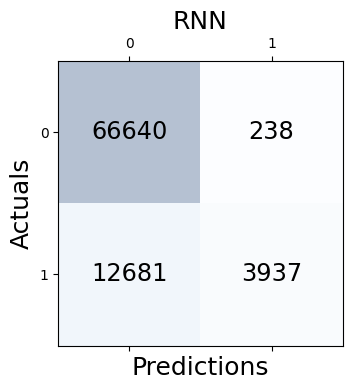

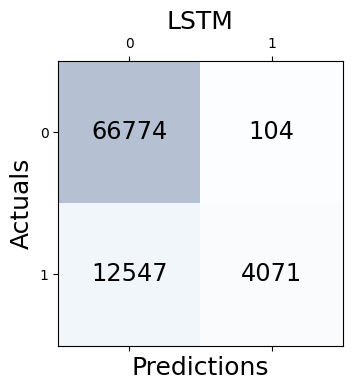

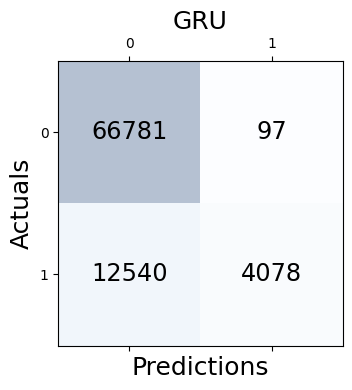

In [116]:
from mlex.plots.confusion_matrix import Plotter
plotter = Plotter()
for y_true, y_pred, y_pred_score in list_ys_true_pred:
    plotter.plot_matrix(y_true, y_pred,name_cycler, filename=f"confusion_{sequence_length}")


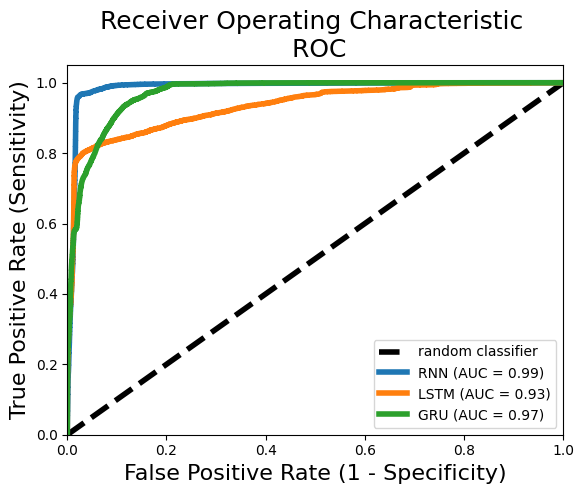

In [117]:
from sklearn import metrics
import cycler
title = "ROC"
fig, ax = plt.subplots()
ax.plot([0,1], [0,1], "k--",linewidth=4, label='random classifier')
for y_true, y_pred, y_pred_score in list_ys_true_pred:
    fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred_score)
    auc = metrics.auc(fpr, tpr)
    ax.plot(fpr, tpr,  linewidth=4, label=f"{next(name_cycler)} (AUC = {round(auc,2) })")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=16)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=16)
ax.set_title(f"Receiver Operating Characteristic \n {title}", fontsize=18)
ax.legend(loc="lower right")
plt.savefig(f"roc_{sequence_length}.pdf")

plt.show()

In [118]:
def roc(y_true, y_pred_score):
    fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred_score)
    auc = metrics.auc(fpr, tpr)
    return auc

In [119]:
import scipy.stats as st

In [120]:
def roc_samples(y_t, y_s):
    N = len(y_t)
    rocs = []
    for b in range(30):
        choices = np.random.choice(N, size=N)
        ys_t = y_t[choices]
        ys_p = y_s[choices]
        fpr, tpr, thresholds = metrics.roc_curve(ys_t, ys_p)
        auc = metrics.auc(fpr, tpr)
        rocs.append(auc)
    return rocs

cis = []
for y_true, y_pred, y_pred_score in list_ys_true_pred:
    rocs = roc_samples(y_true, y_pred_score)
    roc_mean = np.mean(rocs)
    roc_std = np.std(rocs)
    roc_lb = roc_mean - 1.96 * roc_std
    roc_up = roc_mean + 1.96 * roc_std
    ci = f'{round(roc_mean, 2)} {round(roc_lb, 2), round(roc_up, 2)}'
    cis.append(ci)


In [121]:
cis

['0.99 (0.99, 0.99)', '0.93 (0.93, 0.94)', '0.97 (0.97, 0.97)']

In [122]:
import pandas as pd

In [123]:
df_ci = pd.DataFrame({
        "Model": names,
        "95% Confidence Interval": cis
    })
print(df_ci.to_latex(index=False, escape=True))

\begin{tabular}{ll}
\toprule
Model & 95\% Confidence Interval \\
\midrule
RNN & 0.99 (0.99, 0.99) \\
LSTM & 0.93 (0.93, 0.94) \\
GRU & 0.97 (0.97, 0.97) \\
\bottomrule
\end{tabular}

